#📌 Extracción

In [1]:
import pandas as pd
import json

# cargar datos
with open("TelecomX_Data.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)

# ver primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

In [3]:
df.dtypes

customerID                       str
Churn                            str
customer.gender                  str
customer.SeniorCitizen         int64
customer.Partner                 str
customer.Dependents              str
customer.tenure                int64
phone.PhoneService               str
phone.MultipleLines              str
internet.InternetService         str
internet.OnlineSecurity          str
internet.OnlineBackup            str
internet.DeviceProtection        str
internet.TechSupport             str
internet.StreamingTV             str
internet.StreamingMovies         str
account.Contract                 str
account.PaperlessBilling         str
account.PaymentMethod            str
account.Charges.Monthly      float64
account.Charges.Total            str
dtype: object

In [4]:
df.isnull().sum()

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Churn'].unique()
df['customer.gender'].unique()
df['account.Contract'].unique()
df['account.PaymentMethod'].unique()

<StringArray>
[             'Mailed check',          'Electronic check',
   'Credit card (automatic)', 'Bank transfer (automatic)']
Length: 4, dtype: str

Limpieza y corrección de datos


In [7]:
df.columns = df.columns.str.replace(".", "_")


In [8]:
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

In [9]:
df.isnull().sum()

customerID                    0
Churn                         0
customer_gender               0
customer_SeniorCitizen        0
customer_Partner              0
customer_Dependents           0
customer_tenure               0
phone_PhoneService            0
phone_MultipleLines           0
internet_InternetService      0
internet_OnlineSecurity       0
internet_OnlineBackup         0
internet_DeviceProtection     0
internet_TechSupport          0
internet_StreamingTV          0
internet_StreamingMovies      0
account_Contract              0
account_PaperlessBilling      0
account_PaymentMethod         0
account_Charges_Monthly       0
account_Charges_Total        11
dtype: int64

Crear columna Cuentas_Diarias

In [10]:
df = df.drop_duplicates()

In [11]:
df['Cuentas_Diarias'] = df['account_Charges_Monthly'] / 30

In [12]:
df[['account_Charges_Monthly','Cuentas_Diarias']].head()

,account_Charges_Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Estandarización de datos (opcional)

In [13]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

df['customer_Partner'] = df['customer_Partner'].map({'Yes':1,'No':0})
df['customer_Dependents'] = df['customer_Dependents'].map({'Yes':1,'No':0})

#📊 Carga y análisis

Análisis descriptivo

In [14]:
df.describe()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.265370,0.162653,0.484106,0.300124,32.346498,64.720098,2280.634213,2.157337
std,0.441561,0.369074,0.499782,0.458343,24.571773,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


Distribución de evasión (Churn)

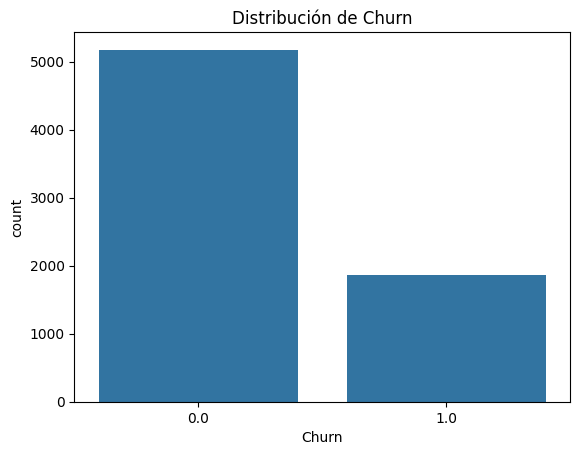

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)

plt.title("Distribución de Churn")
plt.show()

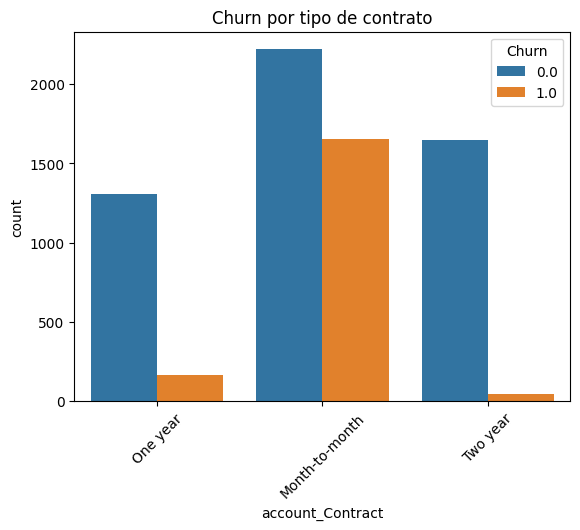

In [16]:
sns.countplot(x='account_Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn por tipo de contrato")
plt.show()

Evasión por variables categóricas

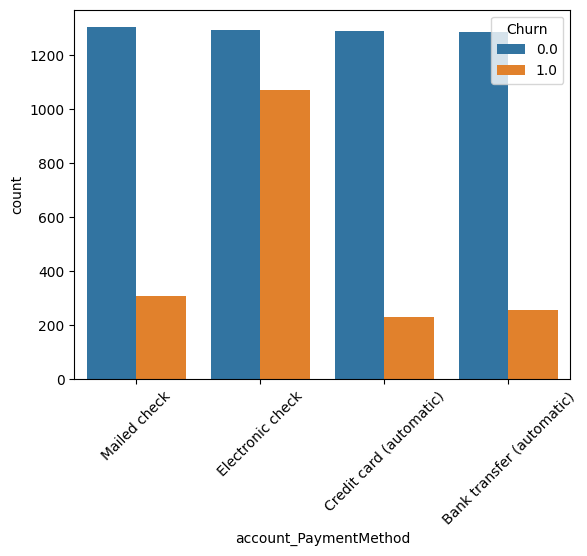

In [17]:
sns.countplot(x='account_PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

Evasión por variables numéricas

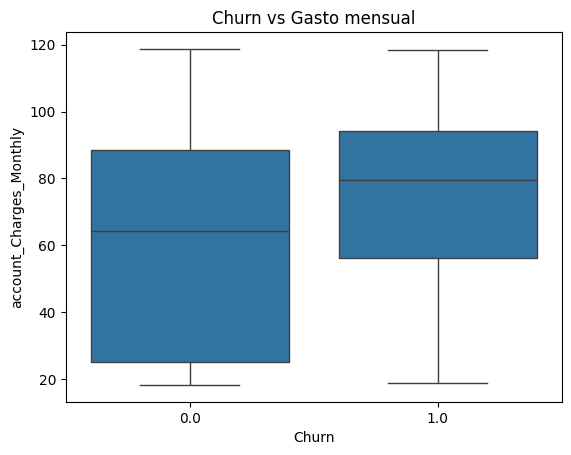

In [18]:
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df)
plt.title("Churn vs Gasto mensual")
plt.show()

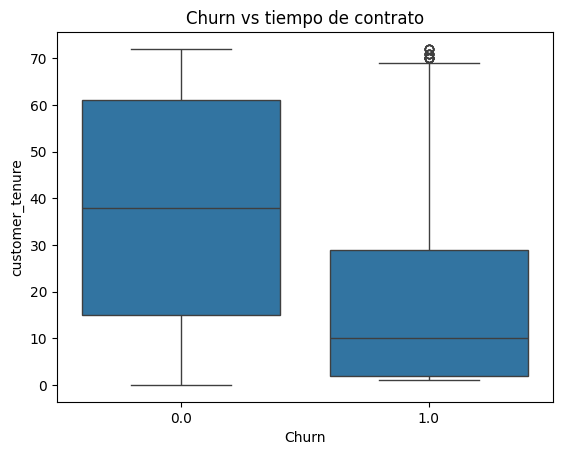

In [19]:
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title("Churn vs tiempo de contrato")
plt.show()

Análisis de correlación (extra)

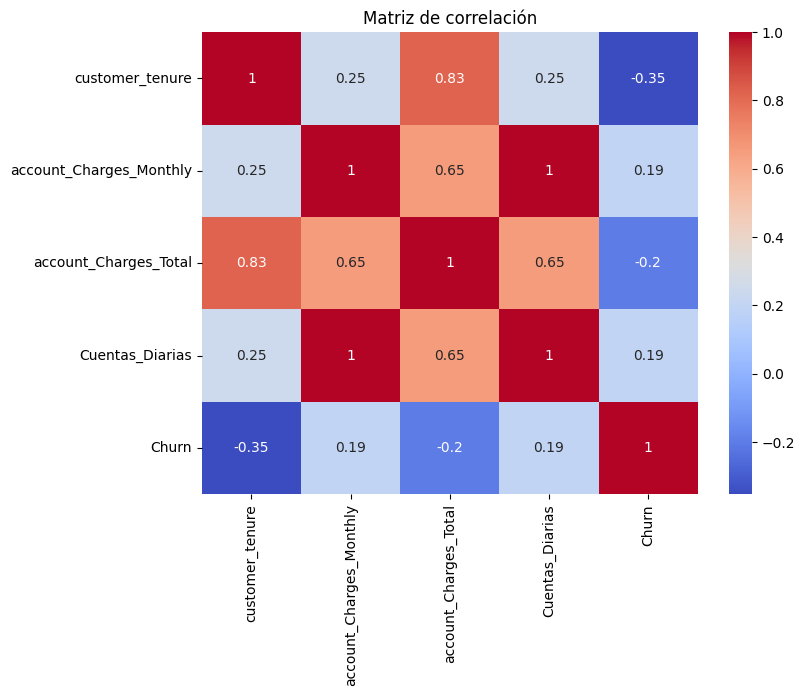

In [20]:
corr = df[['customer_tenure','account_Charges_Monthly','account_Charges_Total','Cuentas_Diarias','Churn']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

#📄Informe final

Introducción

El objetivo de este análisis es estudiar el fenómeno de evasión de clientes (Churn) en la empresa TelecomX. La evasión representa la cancelación del servicio por parte de los clientes y es un problema importante para las empresas de telecomunicaciones, ya que implica pérdida de ingresos y aumento de costos de adquisición de nuevos clientes.

Limpieza y tratamiento de datos

Los datos fueron importados desde un archivo JSON y normalizados en un DataFrame utilizando Pandas.

Durante el proceso de limpieza se realizaron las siguientes acciones:

exploración de tipos de datos

detección de valores faltantes

eliminación de duplicados

estandarización de columnas

creación de la variable Cuentas_Diarias

Estas acciones permitieron preparar los datos para el análisis exploratorio.

Análisis exploratorio

El análisis permitió identificar patrones en la evasión de clientes:

Los contratos mensuales presentan mayor tasa de churn.

Clientes con menor tiempo de permanencia tienden a cancelar más.

Algunos métodos de pago presentan mayor proporción de cancelaciones.

Las visualizaciones ayudaron a comprender mejor estas relaciones.

Conclusiones

Los factores que parecen tener mayor relación con la evasión son:

tipo de contrato

tiempo de permanencia

gasto mensual

servicios contratados

Los clientes con contratos mensuales y menor antigüedad presentan mayor probabilidad de abandonar el servicio.

Recomendaciones

Con base en los resultados se sugieren las siguientes acciones:

incentivar contratos de largo plazo

ofrecer beneficios a clientes nuevos para aumentar su permanencia

mejorar los servicios asociados que generan mayor cancelación

implementar modelos predictivos para identificar clientes en riesgo de churn

Estas estrategias pueden ayudar a reducir la evasión y mejorar la retención de clientes.